In [6]:
import yfinance as yf
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from pytensor.scan import scan

import numpy as np
import pymc as pm
import pytensor.tensor as pt
from pytensor.scan import scan

In [5]:
def observed_stock_var_series(ticker="AAPL", start="2025-08-16", window=20):
    stock_info = yf.download(ticker, start=start, auto_adjust=False, progress=False)

    px = stock_info["Adj Close"].dropna()
    log_returns = np.log(px).diff()

    var_series = log_returns.rolling(window).var(ddof=1)

    var_series = var_series.dropna()
    px_aligned = px.loc[var_series.index]

    return  var_series.to_numpy(dtype=float).ravel(), px_aligned.to_numpy(dtype=float).ravel()

observed_stock_var_series()

(array([2.26353713e-04, 2.26027258e-04, 2.02756852e-04, 2.40488174e-04,
        3.09848509e-04, 3.14003145e-04, 3.22798414e-04, 3.31438941e-04,
        3.36515544e-04, 3.38293038e-04, 3.26775591e-04, 2.69211322e-04,
        2.69500440e-04, 2.68674300e-04, 2.66105057e-04, 2.48189921e-04,
        1.71103145e-04, 1.91453266e-04, 2.60650579e-04, 2.59386566e-04,
        2.58698619e-04, 2.59542826e-04, 2.62085335e-04, 2.31643905e-04,
        2.17166800e-04, 2.13931484e-04, 2.25925563e-04, 2.11273211e-04,
        2.15944115e-04, 2.35982017e-04, 2.35998699e-04, 2.35987188e-04,
        2.35881042e-04, 2.37938131e-04, 2.37725579e-04, 2.37235593e-04,
        2.36734933e-04, 2.19869177e-04, 1.44138701e-04, 1.42657437e-04,
        1.56146426e-04, 1.62983878e-04, 1.57238688e-04, 1.47627502e-04,
        1.01340605e-04, 1.01342694e-04, 8.46352873e-05, 8.98084602e-05,
        1.00587231e-04, 8.86581161e-05, 8.89254041e-05, 8.88800496e-05,
        8.81959408e-05, 9.57399678e-05, 9.61347760e-05, 1.013840

In [62]:
def build_heston_model(S_obs, V_obs):
    dt = 1 / 252
    N = len(S_obs) - 1
    with pm.Model() as m:
        kappa = pm.TruncatedNormal('kappa', mu=5.0, sigma=1.0, lower=0.0)
        theta = pm.Gamma('theta', alpha=2, beta=2)
        xi = pm.HalfNormal('xi', sigma=1.0)
        V0 = pm.TruncatedNormal('V0', mu=1.0, sigma=10.0, lower=0.0)
        r = pm.Normal('r', mu=0.0, sigma=0.1)


        #feller_cond = 2 * kappa * theta - r ** 2
        #pm.Potential('feller', pm.math.switch(feller_cond > 0, 0, -1000 * pm.math.abs(feller_cond)))


        """


        """
        """
        S_pred = np.zeros(N + 1)
        V_pred = np.zeros(N + 1)
        S_pred[0], V_pred[0] = S_obs[0], V_obs[0]

        Z_S = []
        W_V = []

        for i in range(N):
            V_pos = pm.math.maximum(V_obs[i], 0)

            S_drift = S_obs[i] + r * S_obs[i] * dt
            S_vol = pm.math.sqrt(V_pos) * S_obs[i] * pm.math.sqrt(dt)

            V_drift = V_obs[i] + kappa * (theta - V_obs[i]) * dt
            V_vol = xi * pm.math.sqrt(V_pos) * pm.math.sqrt(dt)

            z_s = (S_obs[i + 1] - S_drift) / (S_vol + 1e-8)
            w_v = (V_obs[i + 1] - V_drift) / (V_vol + 1e-8)

            Z_S.append(z_s)
            W_V.append(w_v)

        Z_S = pm.math.stack(Z_S)
        W_V = pm.math.stack(W_V)
        pm.Normal('likelihood_S', mu=0, sigma=1, observed=Z_S)
        pm.Normal('likelihood_V', mu=0, sigma=1, observed=W_V)
                """

    return m

In [63]:
def calibrate_heston_model(S_obs, V_obs, draws=1000, tune=1000):
    model = build_heston_model(S_obs, V_obs)

    with model:
        trace = pm.sample(draws=draws,
                          tune=tune,
                          chains=4,
                          return_inferencedata=True,
                          random_seed=42)
        return trace

V_obs, S_obs = observed_stock_var_series()
calibrate_heston_model(S_obs, V_obs)

TypeError: Variables that depend on other nodes cannot be used for observed data.The data variable was: MakeVector{dtype='float64'}.0

101
101


C:\Users\jayma\AppData\Local\Temp\ipykernel_174916\362575849.py:65: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  y_seq, _ = scan(
Compiling.. :   0%|          | 0/45000 [00:00<?, ?it/s]

  0%|          | 0/45000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/45000 [00:00<?, ?it/s]


  0%|          | 0/45000 [00:00<?, ?it/s]


Running chain 1:   0%|          | 0/45000 [00:02<?, ?it/s]

Running chain 2:   0%|          | 0/45000 [00:02<?, ?it/s]


Running chain 3:   0%|          | 0/45000 [00:02<?, ?it/s]

Running chain 0:   5%|▌         | 2250/45000 [01:05<19:58, 35.68it/s]


Running chain 1:   5%|▌         | 2250/45000 [01:17<19:20, 36.84it/s]

Running chain 2:   5%|▌         | 2250/45000 [01:17<17:46, 40.10it/s]


Running chain 3:   5%|▌         | 2250/45000 [01:27<21:01, 33.90it/s]

Running chain 0:  10%|█         | 4500/45000 [02:16<

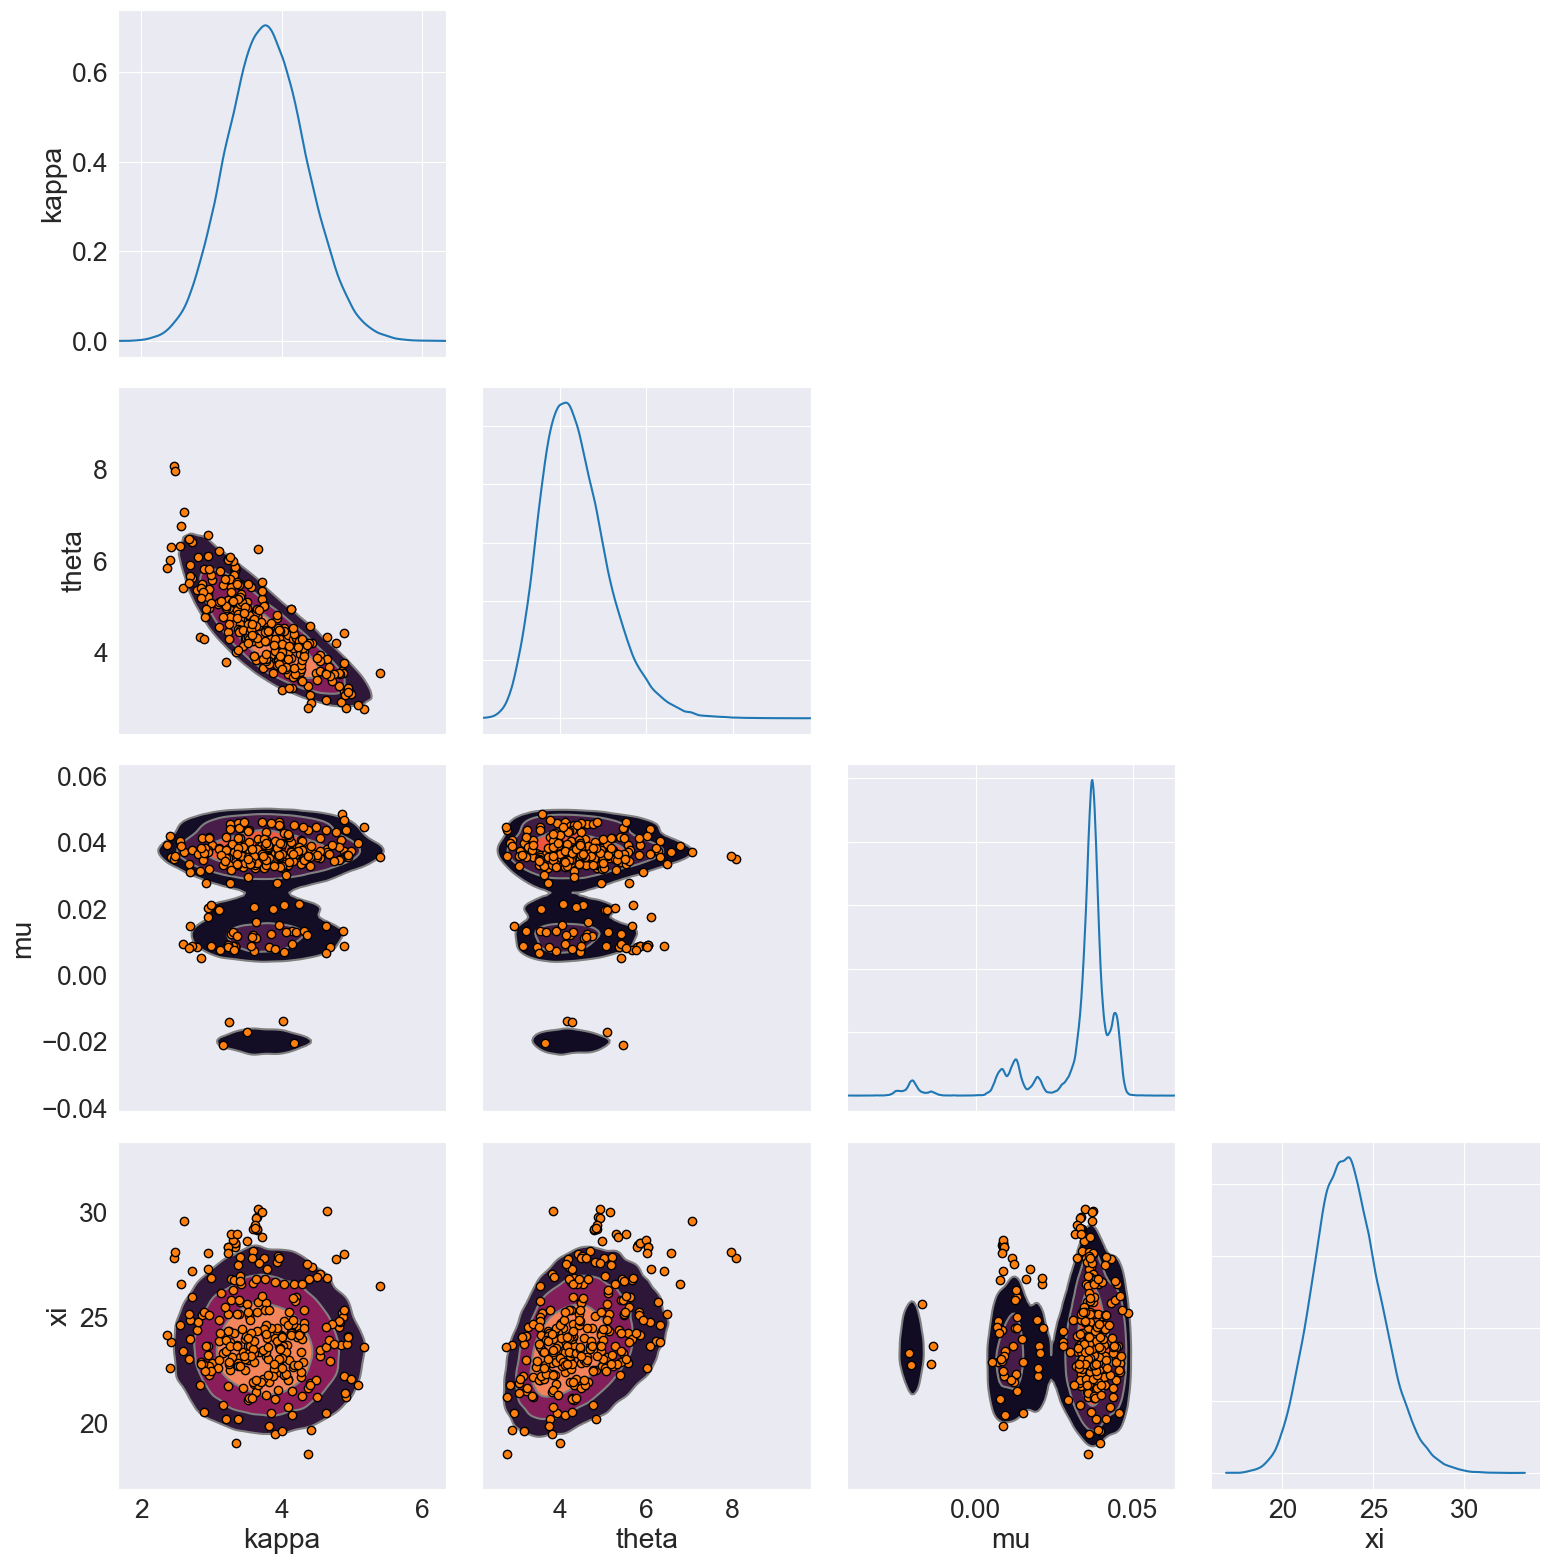

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu      0.032  0.014   0.007    0.047      0.002    0.003     113.0      44.0   
kappa   3.784  0.565   2.748    4.866      0.002    0.002   91510.0   64289.0   
theta   4.373  0.791   2.997    5.876      0.003    0.003   58393.0   62385.0   
xi     23.593  1.845  20.172   27.069      0.016    0.006   13182.0   38815.0   

       r_hat  
mu      1.02  
kappa   1.00  
theta   1.00  
xi      1.00  


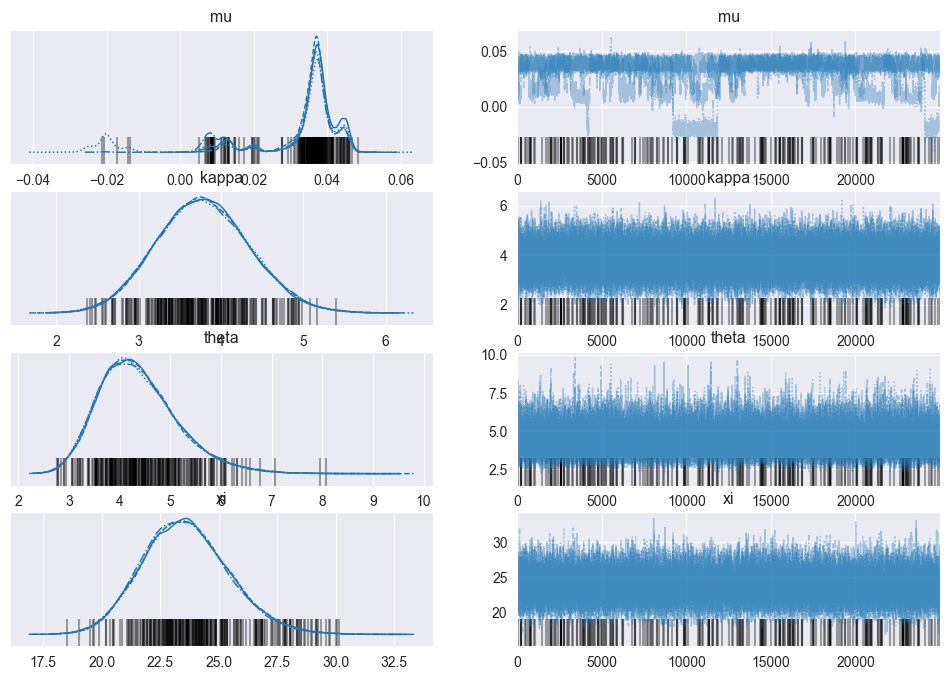

divergences: 280


In [7]:
MU_TRUE = 0.5
KAPPA_TRUE = 2
THETA_TRUE = 1

def softplus(x):
    return pt.log1p(pt.exp(-pt.abs(x))) + pt.maximum(x, 0)

def build_model_state_space_y(
    x_obs,
    h=0.1,
    eps=1e-8,
):
    """
    State-space model for y with *smooth* positivity:

      y_{k+1}^raw = y_k + kappa*(theta - y_k)*h + xi*sqrt(h*y_k)*z_k
      y_{k+1}     = softplus(y_{k+1}^raw) + eps     (smoothly > 0)

    No pt.maximum clamps and no -inf Potentials.

    Constraint 2*kappa*theta > xi enforced via:
      xi = 2*kappa*theta*sigmoid(eta)
    with a regularizing prior on eta to avoid extreme xi unless needed.
    """
    x_obs = np.asarray(x_obs, dtype=float)
    N = len(x_obs)
    if N < 2:
        raise ValueError("Need at least two x observations.")

    x_prev = x_obs[:-1]
    x_next = x_obs[1:]

    with pm.Model() as model:
        # ---- Priors (as given) ----
        mu = pm.Normal("mu", mu=0.5, sigma=np.sqrt(0.01))

        # Use smooth positivity via truncated priors instead of hard Potentials
        kappa = pm.TruncatedNormal("kappa", mu=2.0, sigma=np.sqrt(0.5), lower=eps)
        theta = pm.LogNormal("theta", mu=np.log(1.0), sigma=0.4)

        # Constraint reparam (you already use this idea)
        eta = pm.Normal("eta", mu=-1.0, sigma=0.5)
        xi = pm.Deterministic("xi", 2.0 * kappa * theta * pm.math.sigmoid(eta))

        # ---- Initial latent state y0 > 0 ----
        # (center around 1, fairly weak)
        logy0 = pm.Normal("logy0", mu=0.0, sigma=1)
        y0 = pm.Deterministic("y0", pt.exp(logy0) + eps)

        # ---- Innovations for y ----
        z = pm.Normal("z", mu=0.0, sigma=1.0, shape=N - 1)

        def step(z_k, y_k, kappa, theta, xi):
            # Ensure sqrt argument is positive and smooth
            y_pos = y_k + eps

            drift = y_k + kappa * (theta - y_k) * h
            diff = xi * pt.sqrt(h * y_pos) * z_k
            y_raw = drift + diff

            # Smoothly enforce positivity (no kink)
            y_next = softplus(y_raw) + eps
            return y_next

        y_seq, _ = scan(
            fn=step,
            sequences=[z],
            outputs_info=[y0],
            non_sequences=[kappa, theta, xi],
            strict=True,
        )

        y = pm.Deterministic("y", pt.concatenate([[y0], y_seq]))

        # ---- x likelihood (integrate out w_k) ----
        mean_x = x_prev + mu * x_prev * h
        sd_x = pt.abs(x_prev) * pt.sqrt(y[:-1] + eps) + eps

        x_dist = pm.Normal.dist(mu=mean_x, sigma=sd_x)
        pm.Potential("ll_x", pt.sum(pm.logp(x_dist, x_next)))

    return model

def simulate_heston_discrete(
    N, mu, kappa, theta, xi,
    h = 0.1, x0 = 1.0, y0 = 1.0 ):
    """
    Simulate the discrete-time Heston model
      x(k+1) = x(k) + mu*x(k)*h + sqrt(y(k))*x(k)*w(k)
      y(k+1) = y(k) + kappa*(theta - y(k))*h + xi*sqrt(h*y(k))*z(k)
    where w(k), z(k) iid N(0,1), independent.

    Returns
    -------
    x : ndarray, shape (N+1,)
    y : ndarray, shape (N+1,)
    w : ndarray, shape (N,)   (noise used for x)
    z : ndarray, shape (N,)   (noise used for y)
    """
    rng = np.random.default_rng(1)


    # Pre-generate noises
    w = rng.standard_normal(N)
    z = rng.standard_normal(N)

    x = np.empty(N + 1, dtype=float)
    y = np.empty(N + 1, dtype=float)
    x[0] = float(x0)
    y[0] = float(y0)

    for k in range(N):
        yk_pos = max(y[k], 1e-12)  # used inside sqrt to avoid invalid sqrt

        # le model...
        x[k + 1] = x[k] + mu * x[k] * h + np.sqrt(yk_pos) * x[k] * w[k]
        y_next = y[k] + kappa * (theta - y[k]) * h + xi * np.sqrt(h * yk_pos) * z[k]
        y[k + 1] = max(y_next, 1e-12) # just in case...


    return x, y, w, z

def main():
    # The measurements
    x, _, _, _ = simulate_heston_discrete(N=100,
                                 mu=MU_TRUE,
                                 kappa=KAPPA_TRUE,
                                 theta=THETA_TRUE,
                                 xi = 0.1
                                 )
    print(len(x))
    _, x = observed_stock_var_series()
    print(len(x))

    model = build_model_state_space_y(x, h=0.1)

    with model:
        idata = pm.sample(
            draws=25000,
            tune=20000,
            chains=4,
            target_accept=0.999,
            init="adapt_diag",
            nuts_sampler="numpyro",
            random_seed=1,
        )
    axes = az.plot_pair(
        idata,
        var_names=["kappa", "theta", "mu", "xi"],
        kind="kde",
        marginals=True,
        figsize=(16, 16),
        textsize=19,
        divergences=True
    )
    fig = axes.ravel()[0].figure
    fig.tight_layout(pad=2.0)
    plt.show()


    print(az.summary(idata, var_names=["mu", "kappa", "theta", "xi"]))


    az.plot_trace(idata,
                  var_names=["mu", "kappa", "theta", "xi"])
    plt.show()

    divs = int(idata.sample_stats["diverging"].sum())
    print("divergences:", divs)


if __name__ == "__main__":
    main()